# Интеллектуальный анализ данных – весна 2026

# Домашнее задание 7: Деревья. Случайный лес

Правила:

- Домашнее задание оценивается в 10 баллов.


- Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.


- Можно использовать любые свободные источники с обязательным указанием ссылки на них.


- Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.

<!-- ![](meme.jpg) -->
<img src="meme.jpg" alt="Drawing" style="width: 700px;"/>

Султанбекова Орнелла ИАД-9

## Часть 1: Основы построения решающие дерева (1.5 балла)

В этой части все расчёты необходимо реализовывать в виде запрограммированных формул, например, на `numpy`. **Нельзя использовать готовые реализации**. Например, если в задании требуется рассчитать энтропию, то требуется в каком-то виде релизовать расчёт по формуле, но нельзя использовать готовую реализацию `some_module.entropy()`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Задание 1.1 (0.5 балла)** Пусть известно, что в вершину решающего дерева попали 10 объектов, 8 из которых имеют метку класса $k_1$, а 2 имеют метку класса $k_2$. Рассчитайте энтропию такого распределения классов (с натуральным логарифмом). Ответ округлите до двух знаков после запятой.

In [2]:
p1, p2 = 8/10, 2/10
h = -p1 * np.log(p1) - p2 * np.log(p2)
print(round(h, 2))

0.5


**Задание 1.2 (0.5 балла)** Пусть дополнительно известно, что вершина из предыдущего задания не является листовой и возможно такое разбиение, что в левое поддерево попадут все объекты класса $k_1$, а в правое - класса $k_2$. Посчитайте критерий информативности:

$$
Q(R_m, j, t) = H(R_m) - \frac{|R_\ell|}{|R_m|}H(R_\ell) - \frac{|R_r|}{|R_m|}H(R_r),
$$

где $R_m$ - множество объектов в разбиваемой вершине, $j$ - номер признака, по которому происходит разбиение, $t$ - порог разбиения, $R_\ell$ - множество объектов в левом поддереве, $R_r$ - множество объектов в правом поддереве.

Теперь в качестве $H(R)$ будем использовать индекс Джини:

$$
H(R) = \sum_{k=1}^J p_k(1-p_k),
$$
где $J$ – общее количество классов (в нашем случае, $J = 2$).

Ответ округлите до двух знаков после запятой.

In [3]:
p_rm_1, p_rm_2 = 0.8, 0.2
gini_m = p_rm_1 * (1 - p_rm_1) + p_rm_2 * (1 - p_rm_2)

p1_l, p2_l = 1, 0
gini_l = p1_l * (1 - p1_l) + p2_l * (1 - p2_l)

p1_r, p2_r = 0, 1
gini_r = p1_r * (1 - p1_r) + p2_r * (1 - p2_r)

Q = gini_m - (8/10) * gini_l - (2/10) * gini_r
print(f"Критерий информативности = {Q:.2f}")

Критерий информативности = 0.32


**Задание 1.3 (0.5 балла)** Пусть при построении дерева образовалась листовая вершина с 10 объектами, значения целевой переменной для которых следующие: [1, 10, 5, 18, 100, 30, 50, 61, 84, 47] (решается задача регрессии). Чему будут равны предсказания модели для этих объектов?

In [4]:
v = [1, 10, 5, 18, 100, 30, 50, 61, 84, 47]
print(round(sum(v)/len(v), 2))

40.6


## Часть 2: Решающие деревья (4.5 балла)

В этой части мы напишем и протестируем собственную реализацию решающего дерева.

In [5]:
from collections import Counter
from typing import Dict, List, Tuple, Union

**Задание 2.1 (1.5 балла)** Реализуйте функцию `find_best_split()`, которая должна находить оптимальное разбиение подмножества обучающей выборки в соответствии с информационным критерием из **Задания 1.2**. В качестве меры хаотичности $H(R)$ для задачи регрессии испольуйте дисперсию подвыборки, а для задачи классификации – критерий Джини (определён в том же задании).

Для категориальных признаков применяется наивный алгоритм разбиения: мы пытаемся найти одно значение, разбиение по которому сильнее всего увеличит критерий информативности. Иными словами, объекты с конкретным значением признака отправляем в левое поддерево, остальные - в правое. Обратите внимание, что это далеко не оптимальные способ учёта категориальных признаков. Например, можно было бы на каждое значение категориального признака создавать отдельное поддерево или использовать более сложные подходы. Подробнее об этом можно прочитать в конспектах [лекций](https://github.com/esokolov/ml-course-hse/blob/master/2019-fall/lecture-notes/lecture07-trees.pdf) по машинному обучению на ПМИ (раздел «Учёт категориальных признаков»).

В качестве подсказок реализации можете пользоваться кодом из бонусной части семинара по решающим деревьям.

**Бонус:** Разрешается делать цикл для перебора порогов, но возможна имплементация без него. За имплементацию без цикла – **бонус 1 балл**.

In [6]:
def find_best_split(
    feature_vector: Union[np.ndarray, pd.DataFrame],
    target_vector: Union[np.ndarray, pd.Series],
    task: str = "classification",
    feature_type: str = "real"
) -> Tuple[np.ndarray, np.ndarray, float, float]:
    """
    Указания:
    * Пороги, приводящие к попаданию в одно из поддеревьев пустого множества объектов, не рассматриваются.
    * В качестве порогов, нужно брать среднее двух сосдених (при сортировке) значений признака
    * Поведение функции в случае константного признака может быть любым.
    * При одинаковых приростах Джини или дисперсии нужно выбирать минимальный сплит.
    * За наличие в функции циклов балл будет снижен. Векторизуйте! :)

    :param feature_vector: вещественнозначный вектор значений признака
    :param target_vector: вектор классов объектов,  len(feature_vector) == len(target_vector)
    :param task: либо `classification`, либо `regression`
    :param feature_type: либо `real`, либо `categorical`

    :return thresholds: отсортированный по возрастанию вектор со всеми возможными порогами, по которым объекты можно
     разделить на две различные подвыборки, или поддерева
    :return ginis: вектор со значениями критерия Джини для каждого из порогов в thresholds len(ginis) == len(thresholds)
    :return threshold_best: оптимальный порог (число)
    :return gini_best: оптимальное значение критерия Джини (число)
    """
    # приводим данные в удобный для нас вид :) так как иначе была ошибка:
    # ValueError: Can only compare identically-labeled Series objects
    # дока для ravel - https://www.geeksforgeeks.org/python/numpy-ravel-python/
    x = np.asarray(feature_vector).ravel()
    y = np.asarray(target_vector).ravel()

    sort_indx = np.argsort(x)
    x = x[sort_indx]
    y = y[sort_indx]

    unique_m = x[1:] != x[:-1]

    if not np.any(unique_m):
        return np.array([]), np.array([]), None, -1

    if feature_type == 'real':
        # Для вещественных: среднее между соседями
        thresholds = (x[1:] + x[:-1]) / 2
    else:
        # Для категориальных: само значение
        thresholds = x[:-1]

    thresholds = thresholds[unique_m]

    n = len(y)

    if task == "classification":
        left_size = np.arange(1, n)
        right_size = n - left_size
        # дока для cumsum - https://www.geeksforgeeks.org/numpy/numpy-cumsum-in-python/
        left_positives = np.cumsum(y)[:-1]
        right_positives = np.sum(y) - left_positives

        p1_l = left_positives / left_size
        p0_l = 1 - p1_l
        p1_r = right_positives / right_size
        p0_r = 1 - p1_r

        # Индекс Джини: 1 - (p0^2 + p1^2) = 2 * p0 * p1 (для 2 классов)
        h_l = 2 * p1_l * p0_l
        h_r = 2 * p1_r * p0_r

        p1_all = np.sum(y) / n
        h_parent = 2 * p1_all * (1 - p1_all)

        all_q = h_parent - (left_size / n) * h_l - (right_size / n) * h_r

    elif task == "regression":
        # дисперсия: D = E[X^2] - (E[X])^2
        left_size = np.arange(1, n)
        right_size = n - left_size

        l_sum = np.cumsum(y)[:-1]
        r_sum = np.sum(y) - l_sum
        l_sum_sq = np.cumsum(y**2)[:-1]
        r_sum_sq = np.sum(y**2) - l_sum_sq

        var_l = (l_sum_sq / left_size) - (l_sum / left_size)**2
        var_r = (r_sum_sq / right_size) - (r_sum / right_size)**2

        var_total = np.var(y)
        all_q = var_total - (left_size / n) * var_l - (right_size / n) * var_r

    ginis = all_q[unique_m]

    best_idx = np.argmax(ginis)
    return thresholds, ginis, thresholds[best_idx], ginis[best_idx]

Эту функцию можно протестировать на датасете `California`.

In [7]:
from sklearn.datasets import fetch_california_housing

In [8]:
data = fetch_california_housing()
X = pd.DataFrame(data=data["data"], columns=data["feature_names"])
y = data["target"]
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [9]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

Выведите график зависимости значения критерия ошибки от порогового значения при разбиении вершины по признаку `MedInc`.

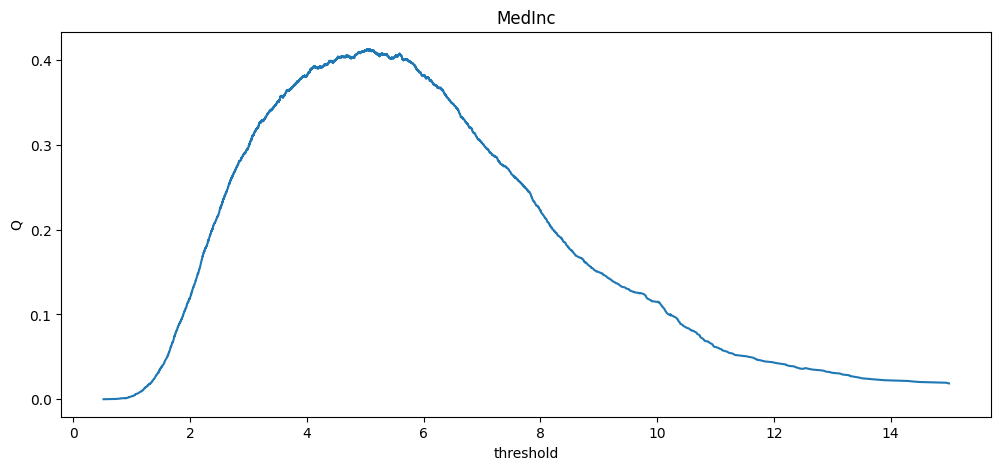

In [10]:
thresholds, Q_s, threshold_best, Q_best = find_best_split(X['MedInc'], y, task="regression", feature_type = "real")
plt.figure(figsize=(12, 5))
plt.plot(thresholds, Q_s)
plt.xlabel("threshold")
plt.ylabel("Q")
plt.title("MedInc")
plt.show()

Найдите лучший, с вашей точки зрения, предикат первой вершины решающего дерева.

In [11]:
best_feature = None
best_threshold = None
best_criterion = -np.inf

for col in X.columns:
    thresholds, criteria, thr, crit = find_best_split(
        X[col].values, y, task="regression", feature_type="real"
    )
    if crit > best_criterion:
        best_criterion = crit
        best_feature = col
        best_threshold = thr

print(f"Лучший предикат: {best_feature}, с порогом: {best_threshold:.4f}")

Лучший предикат: MedInc, с порогом: 5.0351


**Задание 2.2 (1 балл)** Разберитесь с написанным кодом решающего дерева, заполните пропуски в коде и реализуйте недостающий метод `_predict_node()`.

Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в лекции в разделе «Построение дерева».
- **Выбор лучшего разбиения** необходимо производить по критерию Джини.
- **Критерий останова:** все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку.
- **Ответ в листе:** наиболее часто встречающийся класс в листе.

В задаче также предлагается получить два бонуса, по баллу на каждый!

- **Реализуйте способ обрабатывать пропуски в даннх и реализуйте его, пояснив свои действия.**
- **Реализуйте метод оценки важности признаков.**

In [12]:
class DecisionTree:

    def __init__(
        self,
        feature_types: Union[List[str], np.ndarray],
        max_depth: int = None,
        min_samples_split: int = None,
        min_samples_leaf: int = None,
        task: str = "classification"
    ) -> None:

        if np.any(list(map(lambda x: x != "real" and x != "categorical", feature_types))):
            raise ValueError("There is unknown feature type")

        # В этой переменной будем хранить узлы решающего дерева. Каждая вершина хранит в себе идентификатор того,
        # является ли она листовой. Листовые вершины хранят значение класса для предсказания, нелистовые - правого и
        # левого детей (поддеревья для продолжения процедуры предсказания)
        self._tree = {}

        # типы признаков (категориальные или числовые)
        self._feature_types = feature_types

        # гиперпараметры дерева
        self._max_depth = max_depth
        self._min_samples_split = min_samples_split
        self._min_samples_leaf = min_samples_leaf
        self.task = task

        # Переменная, если вы решите делать бонус
        self._feature_importances = {i: 0.0 for i in range(len(feature_types))}

    def _prepare_data(self, X: np.ndarray) -> np.ndarray:
          """
          Обработка пропусков перед обучением.
          """
          X_imp = X.copy()
          for i in range(X_imp.shape[1]):
              mask = np.isnan(X_imp[:, i]) # ищем пропуска
              if np.any(mask): # есть ли в этой колонке хотя бы один пропуск, то вставляем значения
                  if self._feature_types[i] == "real":
                      fill = np.nanmedian(X_imp[:, i]) # для вещественных признаков - медиана (устойчивее к выбросам)
                  else:
                      valid_values = X_imp[~mask, i] # находим моду (самый частый класс) для категориальных
                      fill = Counter(valid_values).most_common(1)[0][0]
                  X_imp[mask, i] = fill
          return X_imp

    def _fit_node(
        self,
        sub_X: np.ndarray,
        sub_y: np.ndarray,
        node: dict
    ) -> None:

        # критерий останова
        if np.all(sub_y == sub_y[0]): # все объекты в листе относятся к одному классу
            node["type"] = "terminal"
            node["class"] = sub_y[0]
            return

        feature_best, threshold_best, gini_best, split = None, None, None, None
        for feature in range(sub_X.shape[1]):
            feature_type = self._feature_types[feature]
            categories_map = {}

            # подготавливаем признак для поиска оптимального порога
            if feature_type == "real":
                feature_vector = sub_X[:, feature]
            elif feature_type == "categorical":
                # здесь могла быть реализация более сложного подхода к обработке категориального признака
                feature_vector = sub_X[:, feature]

            # ищем оптимальный порог
            _, _, threshold, gini = find_best_split(feature_vector, sub_y, self.task, feature_type)

            if gini_best is None or gini > gini_best:
                feature_best = feature
                gini_best = gini

                # split - маска на объекты, которые должны попасть в левое поддерево
                if feature_type == "real":
                    threshold_best = threshold
                    split = feature_vector < threshold
                elif feature_type == "categorical":
                    # в данной реализации это просто значение категории
                    threshold_best = threshold
                    split = feature_vector == threshold
                else:
                    raise ValueError

        # записываем полученные сплиты в атрибуты класса
        if feature_best is None:
            node["type"] = "terminal"
            node["class"] = Counter(sub_y).most_common(1)[0][0]
            return

        self._feature_importances[feature_best] += gini_best * len(sub_y)

        node["type"] = "nonterminal"

        node["feature_split"] = feature_best
        if self._feature_types[feature_best] == "real":
            node["threshold"] = threshold_best
        elif self._feature_types[feature_best] == "categorical":
            node["category_split"] = threshold_best
        else:
            raise ValueError

        node["left_child"], node["right_child"] = {}, {}
        self._fit_node(sub_X[split], sub_y[split], node["left_child"])
        self._fit_node(sub_X[np.logical_not(split)], sub_y[np.logical_not(split)], node["right_child"])

    def _predict_node(self, x: np.ndarray, node: dict) -> int:
        """
        Предсказание начинается с корневой вершины дерева и рекурсивно идёт в левое или правое поддерево в зависимости от значения
        предиката на объекте. Листовая вершина возвращает предсказание.
        :param x: np.array, элемент выборки
        :param node: dict, вершина дерева
        """
        if node["type"] == "terminal":
            return node["class"]

        feature_idx = node["feature_split"]
        if self._feature_types[feature_idx] == "real":
            if x[feature_idx] < node["threshold"]:
                return self._predict_node(x, node["left_child"])
            else:
                return self._predict_node(x, node["right_child"])
        else:
            if x[feature_idx] == node["category_split"]:
                return self._predict_node(x, node["left_child"])
            else:
                return self._predict_node(x, node["right_child"])

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        X = self._prepare_data(X)
        self._fit_node(X, y, self._tree)

    def predict(self, X: np.ndarray) -> np.ndarray:
        predicted = []
        for x in X:
            predicted.append(self._predict_node(x, self._tree))

        return np.array(predicted)

**Задание 2.3 (1 балл)** Загрузите таблицу `students.csv` (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте диаграммы рассеяния "значение признака — класс" для всех пяти признаков.

In [13]:
df = pd.read_csv("students.csv", index_col=0)
df.head()

,STG,SCG,STR,LPR,PEG,UNS
0,0.00,0.00,0.00,0.00,0.00,0
1,0.08,0.08,0.10,0.24,0.90,1
2,0.06,0.06,0.05,0.25,0.33,0
3,0.10,0.10,0.15,0.65,0.30,1
4,0.08,0.08,0.08,0.98,0.24,0


In [14]:
y = df['UNS']
X = df.iloc[:, :5]
X.shape, y.shape

((258, 5), (258,))

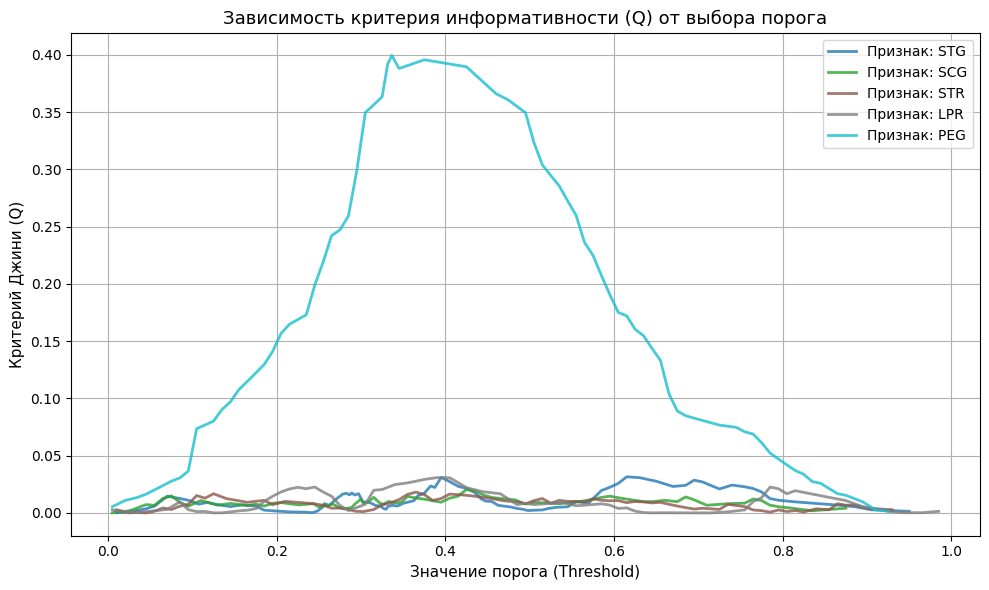

In [15]:
plt.figure(figsize=(10, 6))
plt.title('Зависимость критерия информативности (Q) от выбора порога', fontsize=13)

colors = plt.colormaps['tab10'].resampled(len(X.columns))

for i, col_name in enumerate(X.columns):
    thresholds, q_values, _, _ = find_best_split(
        X[col_name].values,
        y.values,
        task="classification",
        feature_type="real"
    )

    plt.plot(
        thresholds,
        q_values,
        label=f"Признак: {col_name}",
        color=colors(i),
        linewidth=2,
        alpha=0.8
    )
plt.xlabel('Значение порога (Threshold)', fontsize=11)
plt.ylabel('Критерий Джини (Q)', fontsize=11)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

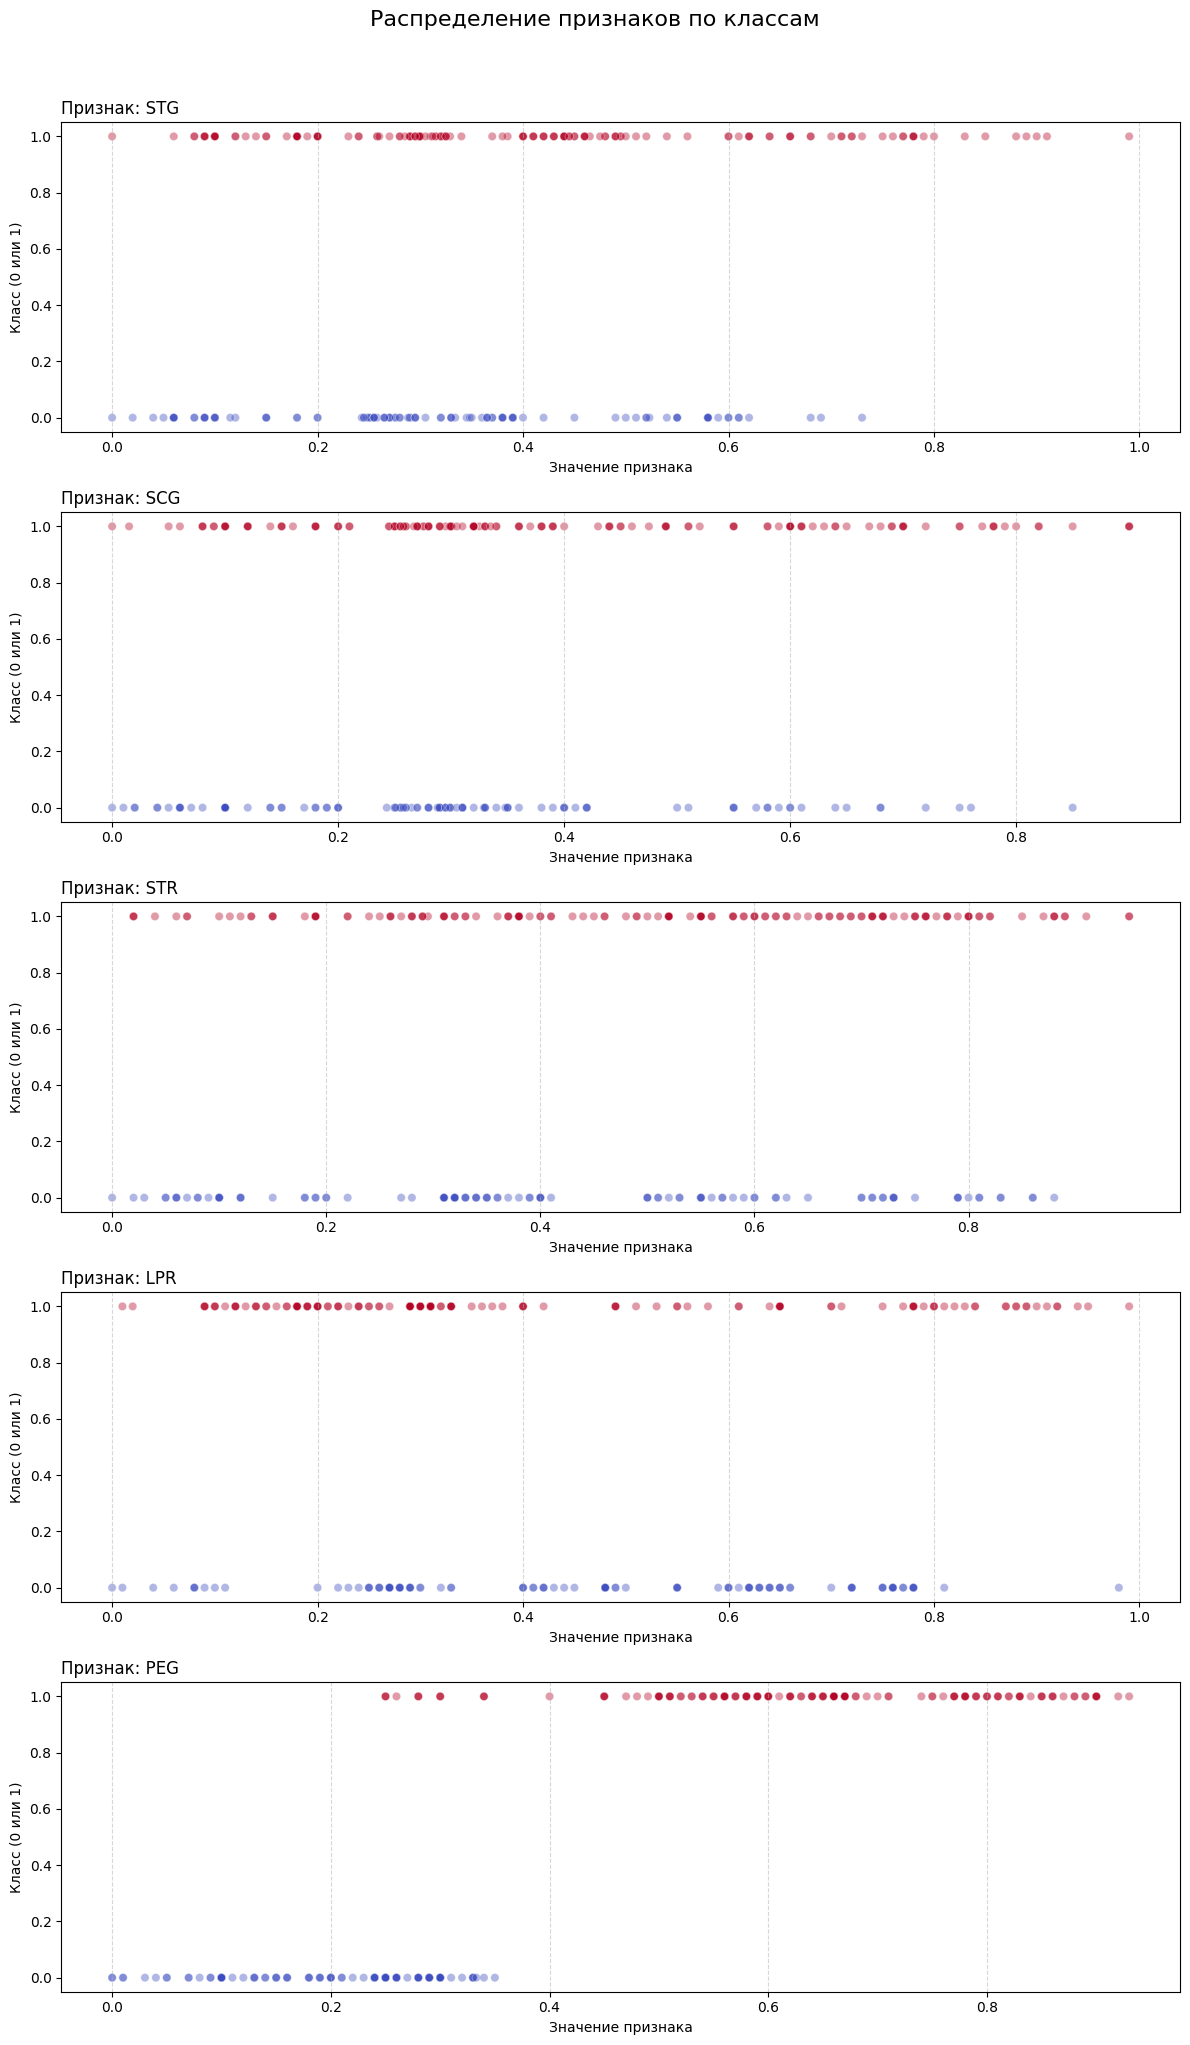

In [16]:
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 20))
fig.suptitle('Распределение признаков по классам', fontsize=16, y=1.02)

for i, col_name in enumerate(X.columns):
    scatter = axes[i].scatter(
        X[col_name],
        y,
        c=y,
        cmap='coolwarm',
        alpha=0.4,
        edgecolors='w',
        linewidth=0.5
    )
    axes[i].set_title(f"Признак: {col_name}", fontsize=12, loc='left')
    axes[i].set_xlabel("Значение признака")
    axes[i].set_ylabel("Класс (0 или 1)")
    axes[i].grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой диаграмм рассеяиния? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

1) Исходя из первого графика, деление следует производить по PEG, потому что достигается максимальный критерий информативности -> в дочерних узлах будет макисмально возможная "чистота" данных на данном этапе.

2) Этот вывод согласуется с диагрммой рассеяния, так как по значению данного признака почти уверенно можно определить класс.
- У признаков STG, SCG, STR, LPR синие (класс 0) и красные (класс 1) точки перемешаны по всей оси значений. Как бы мы ни провели вертикальную черту (порог), в обеих частях окажутся и синие, и красные точки.
- У признака PEG мы видим четкую структуру: слева (примерно до значения 0.35) сконцентрированы в основном синие точки, а после 0.4 начинают преобладать красные. Есть область перекрытия, но она невелика по сравнению с другими признаками.

3) Кривая должна быть похожа на максимально высокий холм/гору, так как это показывает то, что критерий информативности выше, что нам и нужно.

4) Плохие кривые отличаются тем, что они почти линейны, а, следовательно, критерий информативности ≈0

**Задание 2.4 (1 балл)** Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom).

1. Скачайте таблицу `agaricus-lepiota.data` (находится в директории с ноутбуком),
2. Считайте таблицу при помощи `pandas`,
3. Примените к каждому столбцу `LabelEncoder` (из `sklearn`), чтобы преобразовать строковые имена категорий в натуральные числа.

Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

In [17]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score

data = pd.read_csv("agaricus-lepiota.data")
data.head()

,p,x,s,n,t,p.1,f,c,n.1,k,...,s.2,w,w.1,p.2,w.2,o,p.3,k.1,s.3,u
0,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
1,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
2,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
3,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
4,e,x,y,y,t,a,f,c,b,n,...,s,w,w,p,w,o,p,k,n,g


In [18]:
le = LabelEncoder()
data_encoded = data.apply(le.fit_transform)

X = data_encoded.drop(columns=["p"])
y = data_encoded["p"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)
print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (4061, 22)
Размер тестовой выборки: (4062, 22)


In [19]:
feature_types = ['categorical'] * X.shape[1]
tree = DecisionTree(feature_types=feature_types, task='classification')

tree.fit(np.array(X_train), np.array(y_train))
accuracy_train = accuracy_score(tree.predict(np.array(X_train)), y_train)
accuracy_test = accuracy_score(tree.predict(np.array(X_test)), y_test)
print(f'Доля правильных ответов на обучающем наборе: {accuracy_train}, на тестовом наборе: {accuracy_test}')

Доля правильных ответов на обучающем наборе: 1.0, на тестовом наборе: 1.0


## Часть 3: Бэггинг и случайный лес (4 балла)

В данной части мы будем работать [с задачей предсказания диабета у пациента](https://www.kaggle.com/uciml/pima-indians-diabetes-database/data). Посмотрим на работу бэггинга над решающими деревьями и случайного леса, сравним их работу.

In [23]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [24]:
data = pd.read_csv('diabetes.csv')
print(f"Dataset shape: {data.shape}")
data.head()

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Посмотрим на распределение целевой переменной

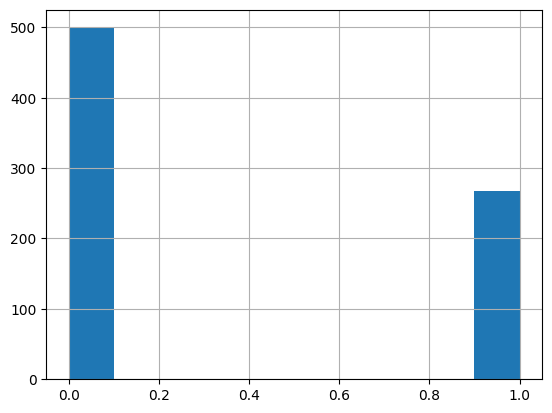

In [25]:
data['Outcome'].hist()
plt.show()

**Задание 3.1 (0.5 балла)** Разделите данные на признаки и целевую переменную. Разбейте датасет на обучающую и тестовую части в отношении 7:3. Затем разделите обучающую выборку на обучающую-обучающую и обучающую-валидационную в соотношении 7:3 (то есть в итоге должно получиться три выборки: обучающая-обучающая (0.49 от исходного датасета), обучающая-валидационная (0.21 от исходного датасета) и тестовая (0.3 от исходного датасета).

In [27]:
X = data.drop('Outcome', axis=1)
y = data['Outcome']

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.3, random_state=42
)
print(f"Train shape: {X_train.shape}\nValidation shape: {X_valid.shape}\nTest shape: {X_test.shape}")

Train shape: (375, 8)
Validation shape: (162, 8)
Test shape: (231, 8)


**Задание 3.2 (1 балл)** На обучающей-валидационной выборке подберите оптимальные значения гиперпараметров `max_depth` и `min_samples_leaf` для `DecisionTreeClassifier`. Для этого:
1. Создайте списки с возможными значениями для перебора.
2. Для каждой пары значений обучите дерево на обучающей-обучающей выборке и определите качество на обучающей-валидационной выборке. В качестве критерия будем использовать `f1-меру`.
3. Выберите ту пару значений, которая даёт наилучшее качество на обучающей-валидационной выборке.


Обучите решающее дерево с подобранными гиперпараметрами на **полной обучающей** выборке. Оцените качество классификации на тестовой выборке по метрикам `accuracy`, `precision` и `recall`, `auc_roc`.

In [28]:
depths = [3, 5, 7, 10, 12, 15, 17, 20, None]
leaves = [1, 5, 10, 15, 20, 30, 50]

best_f1 = -1
best_params = {}

for d in depths:
  for l in leaves:
    dt = DecisionTreeClassifier(max_depth=d, min_samples_leaf=l, random_state=42)
    dt.fit(X_train, y_train)

    y_valid_predict = dt.predict(X_valid)

    current_f1 = f1_score(y_valid, y_valid_predict)

    if current_f1 > best_f1:
      best_f1 = current_f1
      best_params = {'max_depth': d, 'min_samples_leaf': l}

print(f"Лучшие параметры: {best_params}")
print(f"Лучшая F1-мера на валидации: {best_f1:.4f}")

Лучшие параметры: {'max_depth': 5, 'min_samples_leaf': 5}
Лучшая F1-мера на валидации: 0.6667


In [29]:
dt = DecisionTreeClassifier(
    max_depth=best_params['max_depth'],
    min_samples_leaf=best_params['min_samples_leaf'],
    random_state=42,
)
dt.fit(X_train_full, y_train_full)

y_test_predict = dt.predict(X_test)
y_test_proba = dt.predict_proba(X_test)[:, 1]

metrics = {
    'Accuracy': accuracy_score(y_test, y_test_predict),
    'Precision': precision_score(y_test, y_test_predict),
    'Recall': recall_score(y_test, y_test_predict),
    'AUC-ROC': roc_auc_score(y_test, y_test_proba),
}

print("\nРезультаты на тестовой выборке для DecisionTreeClassifier:")
for name, value in metrics.items():
    print(f"{name}: {value:.4f}")


Результаты на тестовой выборке для DecisionTreeClassifier:
Accuracy: 0.7706
Precision: 0.7143
Recall: 0.5625
AUC-ROC: 0.7937


**Задание 3.3 (0.5 балла)** Обучите [`BaggingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html) на 50 деревьях на **полной обучающей** выборке. Оцените качество классификации на тестовой выборке по тем же метрикам.

In [30]:
bg_c = BaggingClassifier(n_estimators=50, random_state=42)
bg_c.fit(X_train_full, y_train_full)

y_test_predict = bg_c.predict(X_test)
y_test_proba = bg_c.predict_proba(X_test)[:, 1]

metrics = {
    'Accuracy': accuracy_score(y_test, y_test_predict),
    'Precision': precision_score(y_test, y_test_predict),
    'Recall': recall_score(y_test, y_test_predict),
    'AUC-ROC': roc_auc_score(y_test, y_test_proba),
}

print("\nРезультаты на тестовой выборке для BaggingClassifier:")
for name, value in metrics.items():
    print(f"{name}: {value:.4f}")


Результаты на тестовой выборке для BaggingClassifier:
Accuracy: 0.7489
Precision: 0.6310
Recall: 0.6625
AUC-ROC: 0.8083


**Задание 3.4 (1 балл)** Выполните кросс-валидацию на полной обучающей выборке и подберите оптимальные значения гиперпараметров `max_depth` и `min_samples_split` для `Random Forest` с 50 деревьями. Для этого:

1. Создайте списки с возможными значениями для перебора.
2. Для каждой пары значений проведите кросс-валидацию на полной обучающей выборке. Количество разбиений выберите на ваш вкус. В качестве критерия будем использовать `f1-меру`. Усредните значение критерия по всем прогонам кросс-валидации.
3. Выберите ту пару значений, которая даёт наилучшее среднее качество.

Обучите случайный лес с подобранными гиперпараметрами на **полной обучающей** выборке. Оцените качество классификации по тем же метрикам. Какая из трёх построенных моделей показала себя лучше?

In [31]:
# дока для cross_val_score - https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html
from sklearn.model_selection import cross_val_score

depths = [3, 5, 10, 15, None]
splits = [2, 5, 10, 20]

best_f1 = -1
best_rf_params = {}

for d in depths:
  for s in splits:
    rf = RandomForestClassifier(
        n_estimators=50,
        max_depth=d,
        min_samples_split=s,
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(rf, X_train_full, y_train_full, cv=5, scoring='f1')
    mean_score = np.mean(scores)

    if mean_score > best_f1:
      best_f1 = mean_score
      best_rf_params = {'max_depth': d, 'min_samples_split': s}

print(f"Лучшие параметры RandomForestClassifier: {best_rf_params}")
print(f"Лучшая F1-CV: {best_f1:.4f}")

Лучшие параметры RandomForestClassifier: {'max_depth': 15, 'min_samples_split': 5}
Лучшая F1-CV: 0.6377


In [32]:
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=best_rf_params['max_depth'],
    min_samples_split=best_rf_params['min_samples_split'],
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_full, y_train_full)

y_predict_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

rf_metrics = {
    "Accuracy": accuracy_score(y_test, y_predict_rf),
    "Precision": precision_score(y_test, y_predict_rf),
    "Recall": recall_score(y_test, y_predict_rf),
    "AUC-ROC": roc_auc_score(y_test, y_proba_rf)
}

print("\nРезультаты Random Forest на тестовой выборке:")
for name, value in rf_metrics.items():
    print(f"{name}: {value:.4f}")


Результаты Random Forest на тестовой выборке:
Accuracy: 0.7143
Precision: 0.5875
Recall: 0.5875
AUC-ROC: 0.7974


BaggingClassifier показал себя лучше всех. Однако, несмотря на это, показатели метрик +- одинаковы у всех моделей.

**Задание 3.5 (0.5 балла)** Постройте график зависимости AUC ROC на тестовой выборке от числа деревьев (`n_estimators`) для случайного леса, обучаемого на **полной обучающей** выборке. Какие выводы можно сделать?

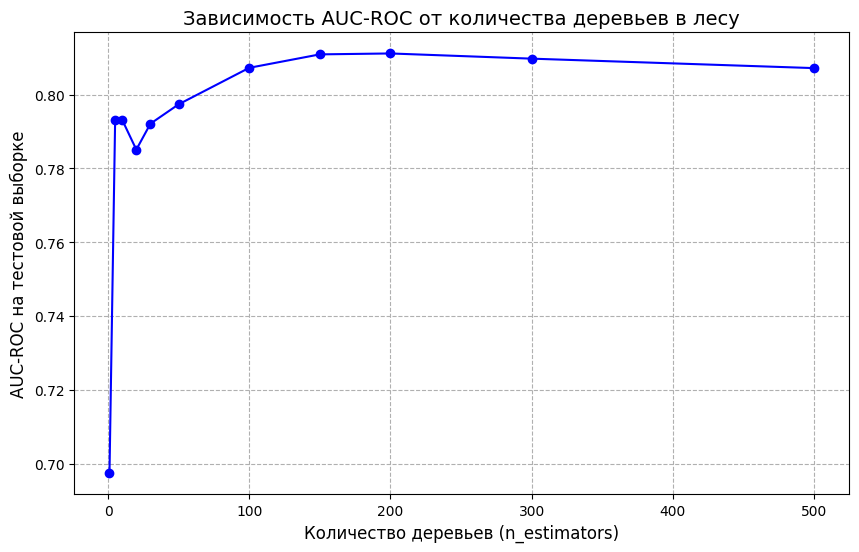

In [33]:
n_estimators_range = [1, 5, 10, 20, 30, 50, 100, 150, 200, 300, 500]
auc_scores = []

for n in n_estimators_range:
    rf = RandomForestClassifier(
        n_estimators=n,
        max_depth=best_rf_params['max_depth'],
        min_samples_split=best_rf_params['min_samples_split'],
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train_full, y_train_full)

    y_proba = rf.predict_proba(X_test)[:, 1]
    auc_scores.append(roc_auc_score(y_test, y_proba))

plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, auc_scores, marker='o', linestyle='-', color='b')
plt.title('Зависимость AUC-ROC от количества деревьев в лесу', fontsize=14)
plt.xlabel('Количество деревьев (n_estimators)', fontsize=12)
plt.ylabel('AUC-ROC на тестовой выборке', fontsize=12)
plt.grid(True, ls='--')
plt.show()

Видно, что в начале график резко растет и в конце превращается в «плато» (выходит на прямую). Следовательно, для данной задачи оптимальное кол-во деревьев 100-150.

**Задание 3.6 (0.5 балла)** Для лучшей модели случайного леса из **Задания 3.4** посчитайте важность признаков и постройте bar plot. Какой признак оказался самым важным для определения диабета?

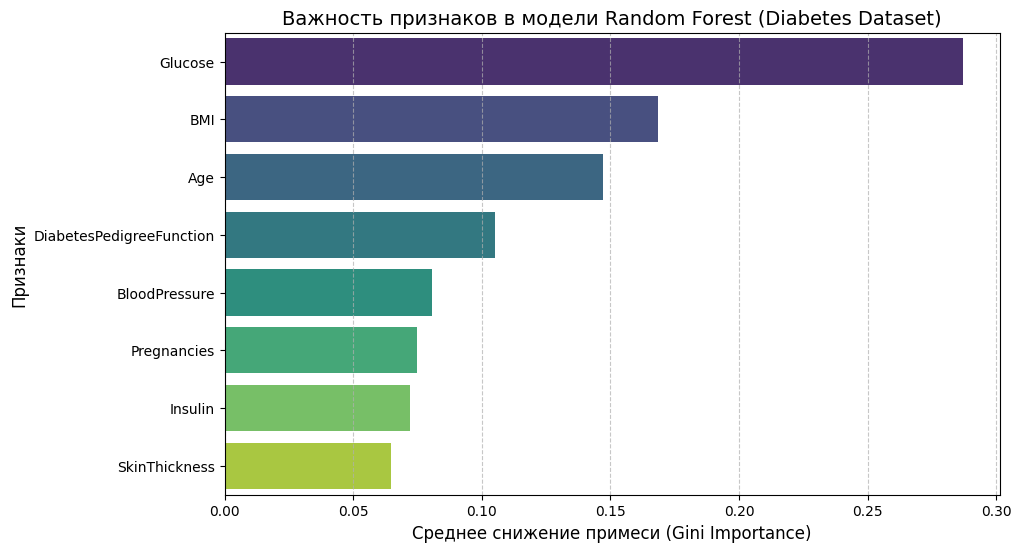

Самый важный признак для определения диабета: Glucose


In [34]:
import seaborn as sns

importances = rf.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df,
    hue='Feature',
    palette='viridis',
    legend=False
)

plt.title('Важность признаков в модели Random Forest (Diabetes Dataset)', fontsize=14)
plt.xlabel('Среднее снижение примеси (Gini Importance)', fontsize=12)
plt.ylabel('Признаки', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

best_feature = feature_importance_df.iloc[0]['Feature']
print(f"Самый важный признак для определения диабета: {best_feature}")